# **02 — RFM Segmentation**

**Goal:** Segment customers by **Recency, Frequency, Monetary (RFM)** value to identify high-value customers, at-risk customers, and dormant ones — the foundation for any retention/marketing strategy.

Uses `outputs/data/cleaned_customer.csv` produced in `data_cleaning.ipynb` (customer-identified sales only).

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'D:\ProProjects\data-analytics-projects\ecom\outputs\data\cleaned_customer.csv', parse_dates=['invoicedate'])
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,iscancellation,totalprice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34


## 1. Computing RFM metrics

- **Recency** — days since each customer's last purchase, measured from one day after the dataset's last transaction (a fixed 'snapshot date')
- **Frequency** — number of distinct invoices (orders) placed
- **Monetary** — total amount spent

In [4]:
snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

rfm = df.groupby('customerid').agg(
    Recency=('invoicedate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('invoiceno', 'nunique'),
    Monetary=('totalprice', 'sum')
).reset_index()

rfm.head()

Snapshot date: 2011-12-10 12:50:00


,customerid,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [5]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


## 2. Score each dimension (1–5)

Using quintiles 
Direction for dimensions: **lower Recency or higher Frequency/Monetary is better** (scored 5).

In [6]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

rfm.head()

,customerid,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4


## 3. Map scores to business-readable segments

A common, recruiter-legible segmentation scheme based on R and F scores.

In [7]:
def segment_customer(row):
    r, f = row['R_Score'], row['F_Score']
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 4:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 3:
        return 'Potential Loyalists'
    elif r == 3 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f == 3:
        return 'Needs Attention'
    elif r <= 2 and f <= 2 and row['M_Score'] >= 3:
        return "Can't Lose Them"
    else:
        return 'Hibernating / Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

Segment
Champions              1139
Hibernating / Lost      821
Potential Loyalists     500
Needs Attention         368
Promising               351
Loyal Customers         321
New Customers           319
At Risk                 275
Can't Lose Them         244
Name: count, dtype: int64

# 4. Segmentation Profile

What does each segment actually look like in terms of customer count, average spend, and share of total revenue?

In [10]:
segment_summary = rfm.groupby('Segment').agg(
    Customers=('customerid', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).sort_values('Total_Revenue', ascending=False)

segment_summary['Pct_of_Customers'] = (segment_summary['Customers'] / segment_summary['Customers'].sum() * 100).round(1)
segment_summary['Pct_of_Revenue'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100).round(1)

segment_summary.round(1)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Pct_of_Customers,Pct_of_Revenue
Segment,,,,,,,
Champions,1139,13.3,10.0,5191.8,5913422.1,26.3,66.5
Loyal Customers,321,50.6,5.7,2410.8,773870.2,7.4,8.7
Potential Loyalists,500,30.0,2.3,1154.4,577214.1,11.5,6.5
At Risk,275,137.1,4.9,1569.6,431639.3,6.3,4.9
Needs Attention,368,164.6,2.3,995.7,366413.2,8.5,4.1
Can't Lose Them,244,183.5,1.3,1355.3,330692.7,5.6,3.7
Hibernating / Lost,821,228.1,1.0,228.5,187629.5,18.9,2.1
Promising,351,53.5,1.2,459.0,161108.1,8.1,1.8
New Customers,319,18.5,1.2,455.2,145219.7,7.4,1.6


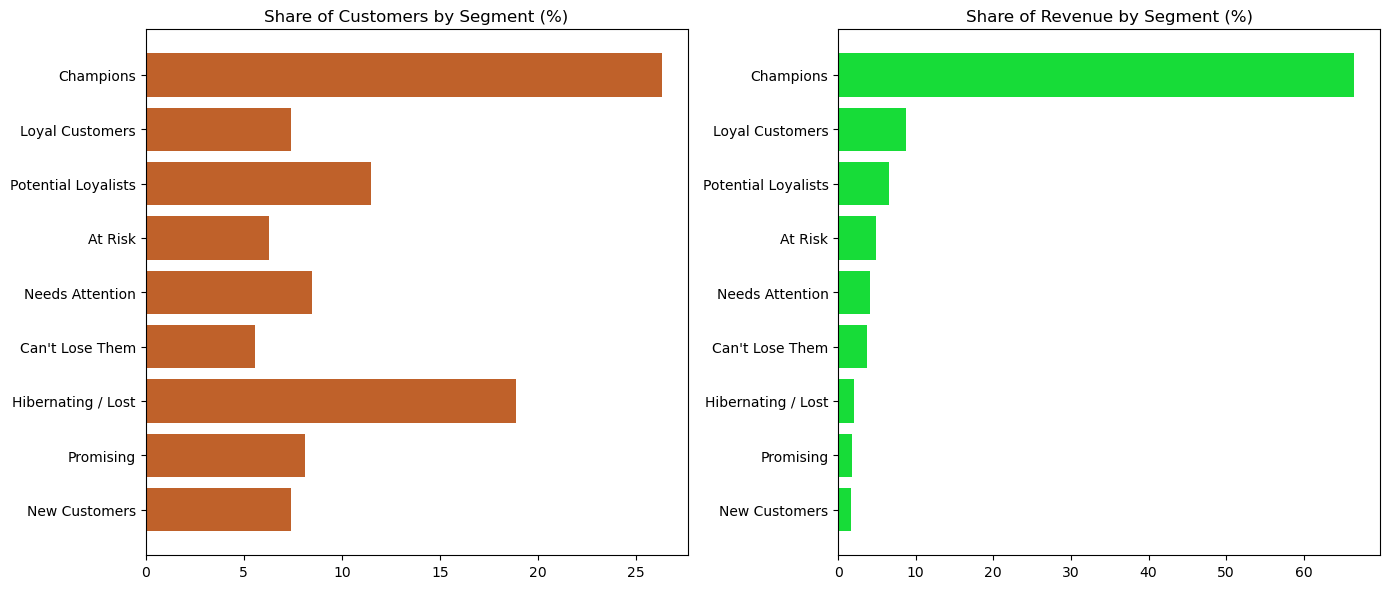

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order = segment_summary.index

axes[0].barh(order, segment_summary['Pct_of_Customers'], color='#BF612A')
axes[0].set_title('Share of Customers by Segment (%)')
axes[0].invert_yaxis()

axes[1].barh(order, segment_summary['Pct_of_Revenue'], color='#17DC38')
axes[1].set_title('Share of Revenue by Segment (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('rfm_segment_share.png', bbox_inches='tight')
plt.show()